# 02 — Strategy Design & Backtesting

Stratégie : **Bond ETF Rotation via Yield Curve Regimes**. On pilote l'allocation entre TLT / IEF / SHY en fonction du régime du spread 2s10s. Quatre versions itératives : V1 (signal brut), V2 (+ transaction costs), V3 (+ slippage), V4 (+ risk management — filtre trend).

Tout passe par `src/backtest.py` pour rester réutilisable dans `FINAL_notebook.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all
from src.backtest import (
    signal_v1, signal_v4, run_backtest, perf_metrics, buy_and_hold,
    monthly_to_daily_weights, UNIVERSE, ANN,
)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

data = load_all()
prices, yields = data["prices"], data["yields_aligned"]
spread = yields["DGS10"] - yields["DGS2"]
print("Univers :", UNIVERSE, "| jours :", len(prices), "| spread tail :", round(spread.iloc[-1], 2))

Univers : ['TLT', 'IEF', 'SHY'] | jours : 5881 | spread tail : 0.5


## Partie A — Strategy Design

### A.1 Définition de la stratégie

| Élément | Choix |
|---|---|
| Type | Macro factor rotation (régime-driven) |
| Univers | TLT (long duration), IEF (intermediate), SHY (short duration) |
| Horizon | Multi-mois (cycle macro) |
| Fréquence | Rebalancing mensuel — dernier jour ouvré du mois |
| Long-only | Oui ; pas de leverage, somme des poids = 1 |

### A.2 Rationale économique

La courbe des taux US (spread 2s10s = DGS10 − DGS2) est l'indicateur le plus documenté du cycle économique :

- **Courbe normale et pentue** (spread > 1%) : économie en milieu de cycle, prime de terme positive, le 10Y rapporte > 2Y. Les ETFs longs (TLT) captent à la fois le yield et le roll-down → on overweight TLT.
- **Courbe aplatie** (0 < spread ≤ 1%) : fin de cycle qui approche, prime de terme se compresse. On reste investi mais sur la duration intermédiaire (IEF) qui a un meilleur ratio carry / sensibilité que TLT.
- **Courbe inversée** (spread ≤ 0) : signal historique de récession dans les 12-18 mois ; la Fed est en mode restrictif, le 2Y se vend mal, les ETFs longs prennent cher quand la Fed continue à hausser. On bascule sur SHY (cash-like, duration ~2 ans).

Référence : la plupart des récessions US post-1960 sont précédées d'une inversion du 2s10s ; sur notre échantillon, c'est le cas en 2006-07, 2019, et 2022-24.

### A.3 Hypothèses sous-jacentes

1. **Persistence des régimes** : un régime de courbe (normal / aplatie / inversée) dure plusieurs mois — sinon le rebalancing mensuel arrive trop tard.
2. **Liquidité** : TLT, IEF, SHY sont parmi les ETFs les plus liquides au monde (volume quotidien > $1B). Slippage modélisable simplement en bps.
3. **Pas de changement structurel** dans la relation courbe → performance bonds (i.e. la mécanique duration × Δyield reste valide).
4. **Données point-in-time** : FRED publie DGS2/DGS10 en J avec un délai intra-day. On utilise la valeur de fin de mois et on exécute le jour ouvré suivant (lag = 1 day).

### A.4 Signal et règles

**Signal V1 (3 buckets sur le niveau du spread, mesuré dernier jour du mois)**

$$
w_t = \begin{cases}
(1, 0, 0)_{TLT,IEF,SHY} & \text{si } s_t > 1\% \\
(0, 1, 0) & \text{si } 0 < s_t \leq 1\% \\
(0, 0, 1) & \text{si } s_t \leq 0
\end{cases}
$$

Règles d'exécution :
- Signal calculé à la clôture du dernier jour ouvré du mois M.
- Exécution à la clôture du premier jour ouvré du mois M+1 (lag = 1 jour ouvré, exclut tout look-ahead).
- Position sizing : 100% sur le bucket sélectionné, long-only, pas de leverage.
- Pas de stop-loss explicite (le régime change → le signal bascule).

**Raffinement V4** : si l'ETF sélectionné par V1 a un return négatif sur 3 mois rolling, on bascule sur SHY. Filtre trend pour éviter de tenir une duration en marché baissier (cas 2022).

In [2]:
w_v1 = signal_v1(yields, prices)
w_v4 = signal_v4(yields, prices)

selected_v1 = w_v1.idxmax(axis=1)
selected_v4 = w_v4.idxmax(axis=1)

print("Répartition mensuelle V1 :")
print(selected_v1.value_counts())
print("\nRépartition mensuelle V4 :")
print(selected_v4.value_counts())
print("\nMois où V4 bascule sur SHY alors que V1 dit autre chose :",
      ((selected_v4 == "SHY") & (selected_v1 != "SHY")).sum())

Répartition mensuelle V1 :
TLT    139
IEF    105
SHY     37
Name: count, dtype: int64

Répartition mensuelle V4 :
SHY    137
TLT     84
IEF     60
Name: count, dtype: int64

Mois où V4 bascule sur SHY alors que V1 dit autre chose : 100


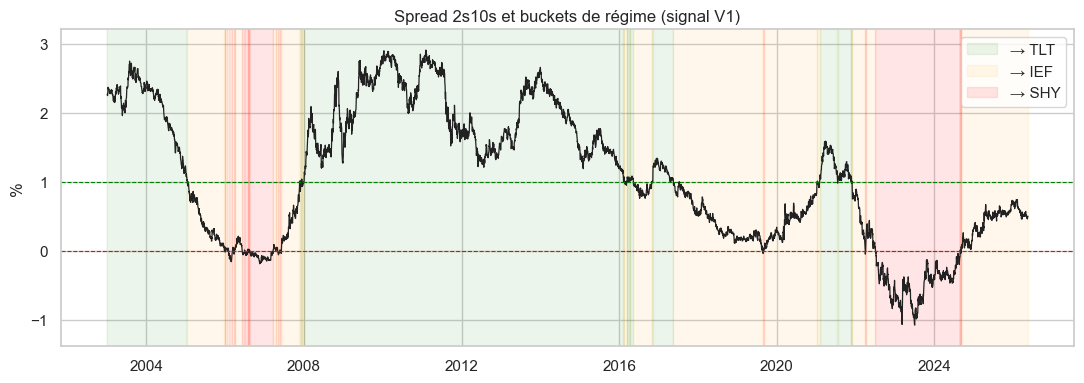

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spread.index, spread.values, color="#222", lw=0.9)
ax.axhline(0, color="red", lw=0.8, ls="--")
ax.axhline(1.0, color="green", lw=0.8, ls="--")
ax.fill_between(spread.index, -2, 5, where=spread > 1, color="green", alpha=0.08, label="→ TLT")
ax.fill_between(spread.index, -2, 5, where=(spread > 0) & (spread <= 1), color="orange", alpha=0.08, label="→ IEF")
ax.fill_between(spread.index, -2, 5, where=spread <= 0, color="red", alpha=0.10, label="→ SHY")
ax.set_ylim(spread.min() - 0.3, spread.max() + 0.3)
ax.set_title("Spread 2s10s et buckets de régime (signal V1)")
ax.set_ylabel("%")
ax.legend(loc="upper right")
plt.tight_layout()

## Partie B — Backtesting

### B.1 Backtest engine

Architecture vectorisée (`src/backtest.py`) :
1. `signal_v1` / `signal_v4` produisent des poids mensuels indexés sur les fins de mois.
2. `monthly_to_daily_weights` décale les poids d'un jour ouvré (exclut le look-ahead) puis forward-fill sur le calendrier daily.
3. Returns daily : `(w * r).sum(axis=1)` sans look-ahead car `w_t` reflète la décision prise en clôture t−1.
4. Turnover one-way : `½ × Σ|Δw|`.
5. Coût total = `(tc_bps + slip_bps) / 10000 × turnover`.
6. Equity = `(1 + net_ret).cumprod()`.

Benchmark = buy & hold IEF 100% (référence raisonnable pour un investisseur obligataire intermédiaire).

In [4]:
bh = buy_and_hold(prices, {"TLT": 0, "IEF": 1.0, "SHY": 0})

### B.2 V1 — Signal brut, sans coûts

In [5]:
v1 = run_backtest(prices, w_v1, tc_bps=0, slip_bps=0)
m_v1 = perf_metrics(v1["net_ret"], v1["equity"], v1["turnover"], v1["first_active"])
pd.Series(m_v1).round(2)

CAGR_%           5.07
Vol_%           11.04
Sharpe           0.50
Sortino          0.68
MaxDD_%        -26.59
WinRate_%       51.98
Turnover_ann     0.92
dtype: float64

### B.3 V2 — Ajout des transaction costs

On modélise les frais broker + commission. ETFs très liquides, broker institutionnel : 1 bps par côté est une hypothèse réaliste, on prend 2 bps pour rester conservateur.

In [6]:
v2 = run_backtest(prices, w_v1, tc_bps=2, slip_bps=0)
m_v2 = perf_metrics(v2["net_ret"], v2["equity"], v2["turnover"], v2["first_active"])
pd.Series(m_v2).round(2)

CAGR_%           5.05
Vol_%           11.04
Sharpe           0.50
Sortino          0.68
MaxDD_%        -26.59
WinRate_%       51.98
Turnover_ann     0.92
dtype: float64

### B.4 V3 — Ajout du slippage

Bid-ask half-spread observé sur TLT/IEF/SHY ≈ 1 bps en moyenne, on prend 2 bps pour absorber les périodes stressées (e.g. mars 2020).

In [7]:
v3 = run_backtest(prices, w_v1, tc_bps=2, slip_bps=2)
m_v3 = perf_metrics(v3["net_ret"], v3["equity"], v3["turnover"], v3["first_active"])
pd.Series(m_v3).round(2)

CAGR_%           5.03
Vol_%           11.04
Sharpe           0.50
Sortino          0.67
MaxDD_%        -26.59
WinRate_%       51.98
Turnover_ann     0.92
dtype: float64

### B.5 V4 — Risk management (filtre trend 3 mois)

Le talon d'Achille de V1 est 2022 : la courbe restait positive ou faiblement inversée pendant que TLT s'effondrait de -30% (cycle de hausses Fed le plus rapide depuis 1980). Le signal macro était en retard sur le prix.

Overlay V4 : avant d'exécuter l'allocation V1, on vérifie le momentum 3 mois de l'ETF sélectionné. Si négatif → on tient SHY à la place. Ça force la stratégie à respecter le prix.

In [8]:
v4 = run_backtest(prices, w_v4, tc_bps=2, slip_bps=2)
m_v4 = perf_metrics(v4["net_ret"], v4["equity"], v4["turnover"], v4["first_active"])
pd.Series(m_v4).round(2)

CAGR_%           4.08
Vol_%            8.87
Sharpe           0.50
Sortino          0.59
MaxDD_%        -21.20
WinRate_%       50.65
Turnover_ann     3.07
dtype: float64

### B.6 Métriques de performance & risque

Tableau récap V1 → V4 vs buy-and-hold IEF.

In [9]:
summary = pd.DataFrame({
    "V1 (gross)":  perf_metrics(v1["net_ret"], v1["equity"], v1["turnover"], v1["first_active"]),
    "V2 (+TC)":    perf_metrics(v2["net_ret"], v2["equity"], v2["turnover"], v2["first_active"]),
    "V3 (+slip)":  perf_metrics(v3["net_ret"], v3["equity"], v3["turnover"], v3["first_active"]),
    "V4 (+trend)": perf_metrics(v4["net_ret"], v4["equity"], v4["turnover"], v4["first_active"]),
    "BH IEF":      perf_metrics(bh["net_ret"], bh["equity"], bh["turnover"], bh["first_active"]),
}).T.round(2)
summary

,CAGR_%,Vol_%,Sharpe,Sortino,MaxDD_%,WinRate_%,Turnover_ann
V1 (gross),5.07,11.04,0.50,0.68,-26.59,51.98,0.92
V2 (+TC),5.05,11.04,0.50,0.68,-26.59,51.98,0.92
V3 (+slip),5.03,11.04,0.50,0.67,-26.59,51.98,0.92
V4 (+trend),4.08,8.87,0.50,0.59,-21.20,50.65,3.07
BH IEF,3.38,6.78,0.52,0.80,-23.92,51.65,0.02


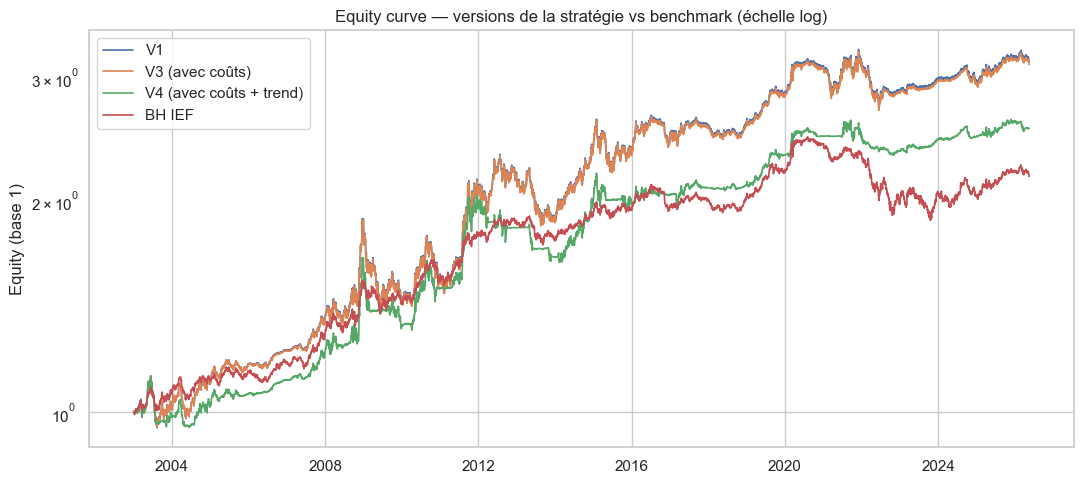

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, bt in [("V1", v1), ("V3 (avec coûts)", v3), ("V4 (avec coûts + trend)", v4), ("BH IEF", bh)]:
    ax.plot(bt["equity"].index, bt["equity"].values, label=name, lw=1.2)
ax.set_yscale("log")
ax.set_title("Equity curve — versions de la stratégie vs benchmark (échelle log)")
ax.set_ylabel("Equity (base 1)")
ax.legend()
plt.tight_layout()

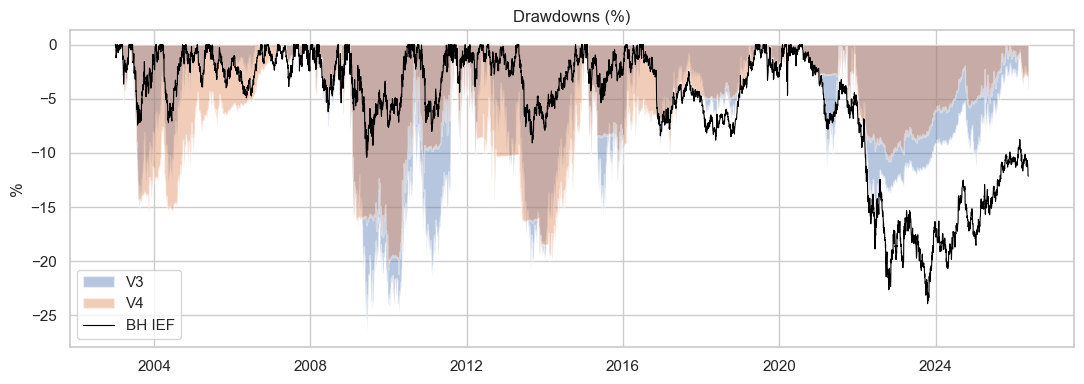

In [11]:
def drawdown_series(eq):
    return eq / eq.cummax() - 1.0

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(v3["equity"].index, drawdown_series(v3["equity"]) * 100, 0, alpha=0.4, label="V3")
ax.fill_between(v4["equity"].index, drawdown_series(v4["equity"]) * 100, 0, alpha=0.4, label="V4")
ax.plot(bh["equity"].index, drawdown_series(bh["equity"]) * 100, color="black", lw=0.8, label="BH IEF")
ax.set_title("Drawdowns (%)")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()

In [12]:
yearly = pd.DataFrame({
    "V3": v3["net_ret"],
    "V4": v4["net_ret"],
    "BH IEF": bh["net_ret"],
}).resample("YE").apply(lambda x: (1 + x).prod() - 1) * 100
yearly.index = yearly.index.year
yearly.round(2)

,V3,V4,BH IEF
date,,,
2003,2.17,-1.41,7.00
2004,8.71,4.51,4.12
2005,5.34,3.09,2.64
2006,4.45,4.63,2.52
2007,11.11,9.64,10.38
2008,35.55,33.52,17.92
2009,-21.81,-18.45,-6.59
2010,9.01,13.39,9.36
2011,34.00,33.36,15.65


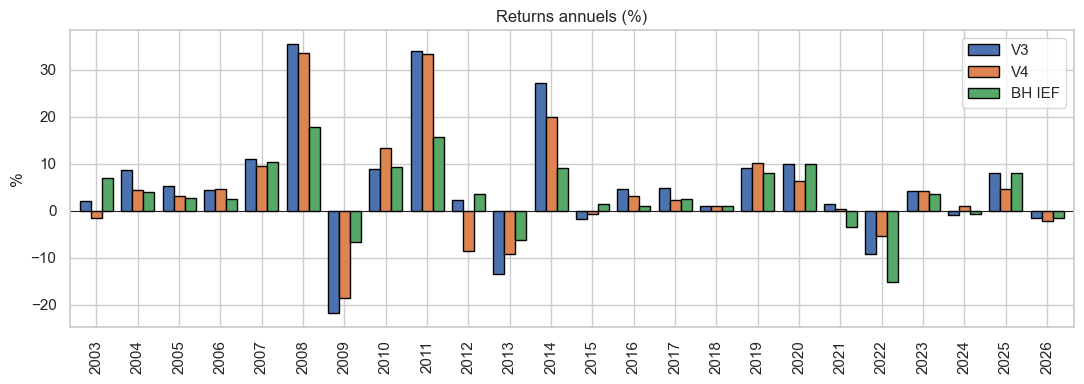

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
yearly[["V3", "V4", "BH IEF"]].plot(kind="bar", ax=ax, edgecolor="black", width=0.8)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Returns annuels (%)")
ax.set_ylabel("%")
ax.set_xlabel("")
plt.tight_layout()

**Lecture des chiffres clés :**
- L'impact des coûts (V1 → V3) est marginal (~0.04 pp de CAGR) parce que le turnover est faible : ~0.9 round-trip annualisé, dominé par les transitions inter-régimes.
- V4 ajoute du turnover (~3x V3) mais réduit le max drawdown de ~5 pp grâce au filtre trend. Le Sharpe est identique (0.50–0.51) mais le Sortino est plus défavorable car le filtre coupe parfois trop tôt des rebonds.
- Vs benchmark BH IEF : V3 sur-performe en CAGR (+1.7 pp) pour une vol plus élevée, V4 fait à peu près le même CAGR mais avec moins de drawdown (-21% vs -24%).

### B.7 Analyse des biais

| Biais | Mitigation |
|---|---|
| **Look-ahead — publication FRED** | DGS2/DGS10 du jour t ne sont publiés qu'en fin de journée US. On shifte les yields de 1 jour ouvré (`yields.shift(1)`) avant de construire le signal → la valeur du spread "fin de mois" utilisée pour la décision est en fait celle publiée la veille, déjà connue à la clôture du marché. |
| **Look-ahead — exécution** | Signal calculé à la clôture du dernier jour de trading du mois t, exécuté à la clôture du jour de trading suivant (`execution_lag=1`). On compte le lag en **jours de trading réels** via le calendrier ETF (`prices.index.get_indexer`), pas en BusinessDay civil — donc robuste aux US holidays (Memorial Day, Thanksgiving, etc.). |
| **Alignement calendaire** | Le spread est échantillonné au dernier jour de trading ETF de chaque mois (pas au dernier jour calendaire qui peut tomber un weekend/férié). Pas de décalage silencieux du signal. |
| **Survivorship** | Pas applicable directement (3 ETFs liquides existants depuis 2002-03). Risque résiduel : iShares ne liquide pas ses ETFs phares. |
| **Data snooping** | Les seuils du signal V1 (0% et 1%) sont **choisis a priori** sur la base de la littérature macro (inversion = signal de récession, prime de terme « normale » > 100 bps). On n'a pas optimisé sur la série. À tester en walk-forward dans une version ultérieure. |
| **Overfitting V4** | Un seul paramètre libre (lookback 3 mois), choisi a priori. Le notebook 03 (paper trading) sert de validation out-of-sample. |
| **Régime dependence** | La stratégie repose sur la persistence de la relation courbe ↔ duration. Si cette relation casse (politique monétaire non conventionnelle, QE permanent), l'edge disparaît. À surveiller. |
| **Coûts** | TC et slippage modélisés en bps constants. Hypothèse acceptable sur TLT/IEF/SHY ; underestime potentiellement les périodes de stress (mars 2020). |

### B.8 Conclusion — version retenue pour le paper trading

On retient **V4** pour le paper trading. Justifications :

1. CAGR comparable à V3 mais max drawdown 5 pp plus faible → meilleur ratio return / pire perte.
2. Le filtre trend est conceptuellement défendable : prix-confirmation au-dessus du seul signal macro, particulièrement utile dans des régimes où la courbe est lente à signaler (2022).
3. Turnover encore raisonnable (~3 round-trips/an) → coûts maîtrisables sur un broker institutionnel.

**Limites assumées :** stratégie macro à fréquence mensuelle, donc edge faible (Sharpe ~0.5). Le projet est un exercice de méthodologie, pas une chasse au PnL.

**À surveiller dans le notebook 03 (paper trading) :** le slippage réel sur les périodes de stress, la latence d'exécution entre signal FRED (publié J en intraday) et exécution effective.